Используя базу "Аудиожанры", примените подход к музыке как к тексту и напишите сверточный классификатор (на базе слоя Conv1D) для подготовленных данных. Для этого:

1. Измените подготовку данных так, чтобы набор признаков, извлекаемый из аудиофайла, был представлен в виде последовательностей векторов признаков. Последовательности должны быть фиксированного размера и выбираться скользящим окном c заданным шагом. Другими словами: берем аудио-файл длительность, например, 30 сек. Берем отрезок фиксированной длины (например, 5с) и получаем набор признаков для этого отрезка. Смещаемся на шаг (например, 1с) и берем следующий отрезок. Таким образом готовим обучающую вборку.
2. Длину последовательности, размер шага и достаточный набор признаков определите самостоятельно исходя из требований к точности классификатора;
3. Разработайте классификатор на одномерных сверточных слоях **Conv1D** с точностью классификации жанра на тестовых данных не ниже **60%**, а на обучающих файлах - **68%** и выше;
4. Используйте за основу материал с урока, но при желании разработайте свои инструменты.

Импортируем необходимые библиотеки:

In [9]:
# Массивы
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt

# Загрузка из google облака
import gdown

# Преобразование категориальных данных в one hot encoding
from tensorflow.keras.utils import to_categorical

# Работа с папками и файлами
import os

# Утилиты работы со временем
import time

# Работа со случайными числами
import random

# Математические функции
import math

# Сохранение и загрузка структур данных Python
import pickle

# Параметризация аудио
import librosa

# Оптимизаторы для обучения моделей
from tensorflow.keras.optimizers import Adam, RMSprop

# Конструирование и загрузка моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model, load_model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, Conv2D, LSTM
from tensorflow.keras.layers import MaxPooling1D, AveragePooling1D, SpatialDropout1D

# Разбиение на обучающую и проверочную выборку
from sklearn.model_selection import train_test_split

# Кодирование категориальных меток, нормирование числовых данных
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, BatchNormalization
%matplotlib inline

Загрузим датасет в Colab:

In [2]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip', None, quiet=True)

'genres.zip'

In [3]:
# Распаковка архива на локальный диск colab
!unzip -qo genres.zip

# Проверка выгруженных папок
!ls genres

# Проверка содержимого одной папки
!ls genres/blues

blues  classical  country  disco  hiphop  jazz	metal  pop  reggae  rock
blues.00000.au	blues.00020.au	blues.00040.au	blues.00060.au	blues.00080.au
blues.00001.au	blues.00021.au	blues.00041.au	blues.00061.au	blues.00081.au
blues.00002.au	blues.00022.au	blues.00042.au	blues.00062.au	blues.00082.au
blues.00003.au	blues.00023.au	blues.00043.au	blues.00063.au	blues.00083.au
blues.00004.au	blues.00024.au	blues.00044.au	blues.00064.au	blues.00084.au
blues.00005.au	blues.00025.au	blues.00045.au	blues.00065.au	blues.00085.au
blues.00006.au	blues.00026.au	blues.00046.au	blues.00066.au	blues.00086.au
blues.00007.au	blues.00027.au	blues.00047.au	blues.00067.au	blues.00087.au
blues.00008.au	blues.00028.au	blues.00048.au	blues.00068.au	blues.00088.au
blues.00009.au	blues.00029.au	blues.00049.au	blues.00069.au	blues.00089.au
blues.00010.au	blues.00030.au	blues.00050.au	blues.00070.au	blues.00090.au
blues.00011.au	blues.00031.au	blues.00051.au	blues.00071.au	blues.00091.au
blues.00012.au	blues.00032.a

In [4]:
# Ваше решение

# ПАРАМЕТРЫ

DATA_DIR = 'genres'

SR = 22050               # частота дискретизации
TRACK_DURATION = 30      # длина файла в секундах

WINDOW_SEC = 3           # длина окна
STEP_SEC = 1             # шаг окна

WINDOW_SIZE = WINDOW_SEC * SR
STEP_SIZE = STEP_SEC * SR


# ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ИЗ ОКНА


def extract_features(y, sr):

    # log-mel спектрограмма(представление сигнала в частотно-временной области)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40)
    log_mel = librosa.power_to_db(mel)

    #компактное представление спектральной огибающей
    mfcc = librosa.feature.mfcc(S=log_mel, sr=sr, n_mfcc=20)

    features = []

    # статистики по времени (сжатие временной оси)
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))

    features.extend(np.mean(log_mel, axis=1))
    features.extend(np.std(log_mel, axis=1))

    return np.array(features)

# СОЗДАНИЕ ПОСЛЕДОВАТЕЛЬНОСТЕЙ

X = []
y = []

genres = sorted(os.listdir(DATA_DIR))

print('Жанры:', genres)


for genre in genres:


    genre_path = os.path.join(DATA_DIR, genre)

    # Получаем список всех аудиофайлов в этой папке
    files = os.listdir(genre_path)


    for file_name in files:

        # Фильтруем только аудиофайлы нужных форматов

        if not file_name.endswith(('.wav', '.au')):
            continue

        # Полный путь к конкретному аудиофайлу
        file_path = os.path.join(genre_path, file_name)

        try:

            # librosa приводит все файлы к единой частоте дискретизации (SR)
            # и ограничивает длину чтобы данные были сопоставимы
            signal, sr = librosa.load(
                file_path,
                sr=SR,
                duration=TRACK_DURATION
            )

            #последовательность признаков для одного файла
            sequence = []


            #  не используем весь сигнал целиком,
            #  разбиваем его на короткие фрагменты фиксированной длины
            for start in range(0, len(signal) - WINDOW_SIZE, STEP_SIZE):

                # Вырезаем фрагмент аудио фиксированной длительности
                fragment = signal[start:start + WINDOW_SIZE]

                # Извлекаем признаки
                feats = extract_features(fragment, sr)
                sequence.append(feats)


            sequence = np.array(sequence)

            if len(sequence) == 0:
                continue

            # Добавляем пример в общий датасет

            X.append(sequence)
            y.append(genre)

        except Exception as e:
            # Если файл повреждён или не читается — просто пропускаем его

            print(f'Ошибка в файле {file_name}: {e}')


# ВЫРАВНИВАНИЕ ДЛИНЫ ПОСЛЕДОВАТЕЛЬНОСТЕЙ
max_len = max(len(x) for x in X)

X = np.array([
    np.pad(x, ((0, max_len - len(x)), (0, 0)))
    for x in X
])

y = np.array(y)

print('X shape:', X.shape)
print('y shape:', y.shape)

Жанры: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
X shape: (1000, 27, 120)
y shape: (1000,)


In [5]:
count = 0

for genre in genres:
    for file_name in os.listdir(os.path.join(DATA_DIR, genre))[:5]:

        file_path = os.path.join(DATA_DIR, genre, file_name)

        signal, sr = librosa.load(file_path, sr=SR, duration=TRACK_DURATION)



In [6]:
# КОДИРОВАНИЕ МЕТОК

encoder = LabelEncoder()
# перевод строковых меток в числа
y_encoded = encoder.fit_transform(y)

y_cat = to_categorical(y_encoded)

from sklearn.utils import shuffle

X, y_cat, y_encoded = shuffle(
    X, y_cat, y_encoded,
    random_state=42
)

# TRAIN / TEST

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(800, 27, 120)
(200, 27, 120)


In [7]:
# НОРМАЛИЗАЦИЯ

n_samples, n_steps, n_features = X_train.shape

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

X_train_scaled = scaler.fit_transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train_scaled = X_train_scaled.reshape(
    X_train.shape
)

X_test_scaled = X_test_scaled.reshape(
    X_test.shape
)

print(X_train_scaled.shape)

(800, 27, 120)


In [38]:
from tensorflow.keras.layers import GlobalMaxPooling1D
model = Sequential()

model.add(Conv1D(64, 5, activation='relu',
                 input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(SpatialDropout1D(0.1))

model.add(Conv1D(128, 3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(GlobalMaxPooling1D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(y_cat.shape[1], activation='softmax'))

In [39]:
# ОБУЧЕНИЕ
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.1163 - loss: 3.0621 - val_accuracy: 0.1900 - val_loss: 2.2333
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2313 - loss: 2.2723 - val_accuracy: 0.3450 - val_loss: 1.9510
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3613 - loss: 1.8425 - val_accuracy: 0.4950 - val_loss: 1.7552
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4425 - loss: 1.6509 - val_accuracy: 0.5150 - val_loss: 1.6187
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4787 - loss: 1.5251 - val_accuracy: 0.5250 - val_loss: 1.5174
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5213 - loss: 1.4342 - val_accuracy: 0.5400 - val_loss: 1.4252
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5425 - loss: 1.3693 - val_accuracy: 0.5700 - val_loss: 1.3513
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5537 - loss: 1.2600 - val_accuracy: 0.6050 - val_loss

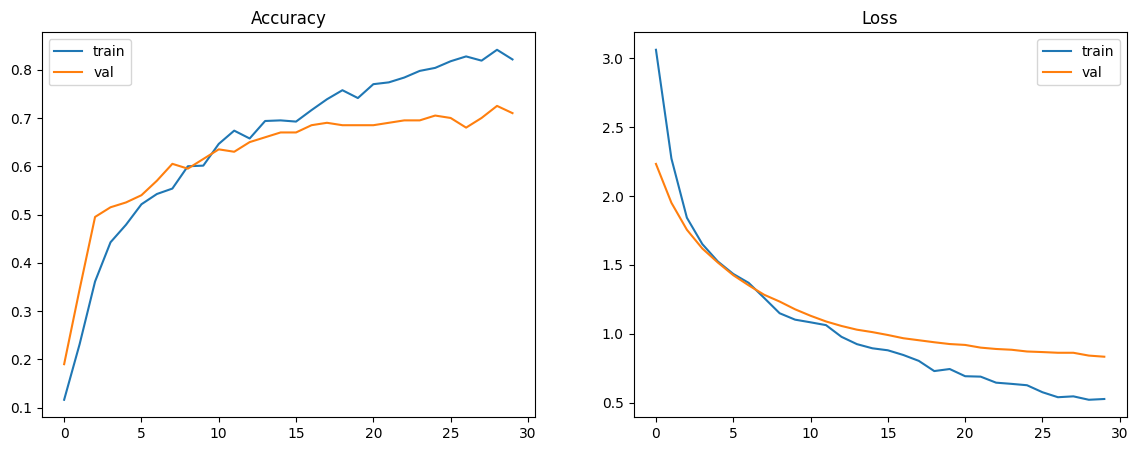

In [40]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['train', 'val'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['train', 'val'])

plt.show()